In [4]:
%load_ext sql
%config SqlMagic.autopandas = True
%sql duckdb:///:memory:


Connecting to 'duckdb:///:memory:'

In [5]:
%%sql
SELECT * 
FROM read_parquet('/Users/brianbradley/Downloads/part-00000-1ad784d7-3b13-4292-9db5-9aa9ae3b50a7-c000.snappy.parquet')
LIMIT 10;


Running query in 'duckdb:///:memory:'

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2026-04-01 00:40:05,2026-04-01 00:52:44,1,2.80,1,N,237,68,1,15.6,4.25,0.5,4.25,0.00,1.0,25.60,2.5,0.0,0.75
1,2,2026-04-01 00:09:19,2026-04-01 00:21:29,1,7.37,1,N,138,75,1,28.2,6.00,0.5,9.03,7.46,1.0,54.19,0.0,2.0,0.00
2,2,2026-04-01 00:15:29,2026-04-01 00:34:14,1,7.66,1,N,138,112,1,31.7,6.00,0.5,5.00,0.00,1.0,46.20,0.0,2.0,0.00
3,2,2026-04-01 00:04:53,2026-04-01 00:11:54,1,1.34,1,N,230,234,1,8.6,1.00,0.5,2.87,0.00,1.0,17.22,2.5,0.0,0.75
4,2,2026-04-01 00:37:00,2026-04-01 00:45:17,1,1.74,1,N,68,107,1,10.7,1.00,0.5,4.93,0.00,1.0,21.38,2.5,0.0,0.75
5,2,2026-04-01 00:01:45,2026-04-01 00:11:27,1,2.68,1,N,236,41,1,13.5,1.00,0.5,1.85,0.00,1.0,20.35,2.5,0.0,0.00
6,2,2026-04-01 00:30:02,2026-04-01 00:38:59,3,1.38,1,N,161,246,2,10.0,1.00,0.5,0.00,0.00,1.0,15.75,2.5,0.0,0.75
7,1,2026-04-01 00:14:55,2026-04-01 00:24:35,1,2.40,1,N,142,68,1,12.8,4.25,0.5,3.70,0.00,1.0,22.25,2.5,0.0,0.75
8,1,2026-04-01 00:17:23,2026-04-01 00:29:52,1,7.30,1,N,70,263,1,29.6,8.00,0.5,9.30,7.46,1.0,55.86,0.0,2.0,0.00
9,1,2026-04-01 00:58:58,2026-04-01 01:01:19,1,0.80,1,N,143,238,1,5.8,3.50,0.5,2.15,0.00,1.0,12.95,2.5,0.0,0.00


In [6]:
%%sql
SELECT 
    EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,
    COUNT(*) AS total_trips,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(tip_amount), 2) AS avg_tip,
    ROUND(AVG(tip_amount) / NULLIF(AVG(fare_amount), 0) * 100, 2) AS tip_percentage
FROM read_parquet('/Users/brianbradley/Downloads/part-00000-1ad784d7-3b13-4292-9db5-9aa9ae3b50a7-c000.snappy.parquet')
GROUP BY 1
ORDER BY tip_percentage DESC;


Running query in 'duckdb:///:memory:'

,pickup_hour,total_trips,avg_fare,avg_tip,tip_percentage
0,19,63313,18.51,3.76,20.29
1,18,72254,18.14,3.66,20.19
2,21,57825,18.79,3.77,20.07
3,20,58969,18.62,3.69,19.82
4,22,49166,19.40,3.80,19.58
5,17,71984,19.20,3.75,19.54
6,23,34805,20.54,3.88,18.89
7,16,68280,20.72,3.91,18.86
8,0,24003,21.31,3.81,17.87
9,1,14961,18.91,3.36,17.79


In [7]:
%%sql
SELECT 
    EXTRACT(MONTH FROM tpep_pickup_datetime) AS pickup_month,
    COUNT(*) AS total_trips,
    ROUND(SUM(total_amount), 2) AS total_revenue,
    ROUND(AVG(trip_distance), 2) AS avg_distance
FROM read_parquet('/Users/brianbradley/Downloads/cleaned_2026_taxi_data.parquet')
GROUP BY 1
ORDER BY 1 ASC;


Running query in 'duckdb:///:memory:'

,pickup_month,total_trips,total_revenue,avg_distance
0,1,5,230.83,5.00
1,3,7,253.74,5.86
2,4,2924166,86362198.61,3.50
3,5,3022778,90617372.32,3.44
4,6,1,66.25,11.11
5,12,1,26.94,2.28


In [9]:
import matplotlib.pyplot as plt

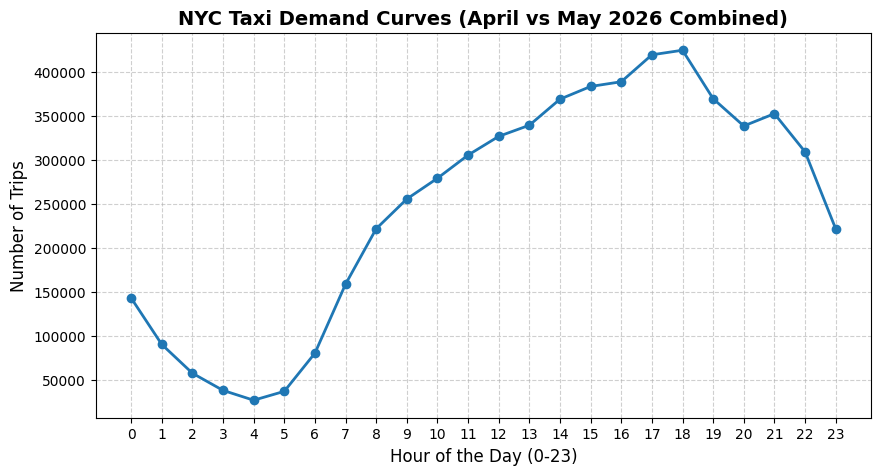

In [13]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the SQL query result straight into a Pandas Dataframe using DuckDB
df = duckdb.sql("""
    SELECT 
        EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,
        COUNT(*) AS trip_count
    FROM read_parquet('/Users/brianbradley/Downloads/cleaned_2026_taxi_data.parquet')
    GROUP BY 1 
    ORDER BY 1
""").to_df()

# 2. Plot an elegant line chart showing the busiest hours of the day
plt.figure(figsize=(10, 5))
plt.plot(df['pickup_hour'], df['trip_count'], marker='o', color='tab:blue', linewidth=2)
plt.title('NYC Taxi Demand Curves (April vs May 2026 Combined)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0, 24))
plt.show()


In [14]:
%%sql
SELECT 
    MIN(total_amount) AS cheapest_ride,
    MAX(total_amount) AS most_expensive_ride,
    AVG(total_amount) AS average_ride
FROM read_parquet('/Users/brianbradley/Downloads/cleaned_2026_taxi_data.parquet');


Running query in 'duckdb:///:memory:'

,cheapest_ride,most_expensive_ride,average_ride
0,-6.75,1760.55,29.759778


In [15]:
%%sql
WITH hourly_metrics AS (
    SELECT 
        -- 1 = Sunday, 2 = Monday, etc. (DuckDB format)
        DAYOFWEEK(tpep_pickup_datetime) AS day_of_week,
        EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,
        COUNT(*) AS total_trips,
        ROUND(AVG(tip_amount), 2) AS avg_tip,
        -- Calculate what rank this hour is for THIS specific day
        RANK() OVER(
            PARTITION BY DAYOFWEEK(tpep_pickup_datetime) 
            ORDER BY AVG(tip_amount) DESC
        ) AS tip_rank
    FROM read_parquet('/Users/brianbradley/Downloads/cleaned_2026_taxi_data.parquet')
    GROUP BY 1, 2
)
SELECT 
    CASE day_of_week 
        WHEN 1 THEN 'Sunday' WHEN 2 THEN 'Monday' WHEN 3 THEN 'Tuesday'
        WHEN 4 THEN 'Wednesday' WHEN 5 THEN 'Thursday' WHEN 6 THEN 'Friday' 
        WHEN 7 THEN 'Saturday' END AS day_name,
    pickup_hour,
    total_trips,
    avg_tip
FROM hourly_metrics
WHERE tip_rank = 1 -- Only show the absolute best hour for each day
ORDER BY avg_tip DESC;


Running query in 'duckdb:///:memory:'

,day_name,pickup_hour,total_trips,avg_tip
0,None,23,17922,5.00
1,Sunday,0,9528,4.89
2,Monday,0,9635,4.64
3,Wednesday,16,63314,4.30
4,Tuesday,16,60935,4.18
5,Thursday,16,59233,4.05
6,Friday,5,3795,4.02
